
Loading MNIST Data...

Loading Training Data...

Loading Testing Data...

Preparing Classifier Training and Validation Data...

SVM Classifier with gamma = 0.1; Kernel = polynomial

Pickling the Classifier for Future Use...

Calculating Accuracy of trained Classifier...

Making Predictions on Validation Data...

Calculating Accuracy of Predictions...

Creating Confusion Matrix...

SVM Trained Classifier Accuracy:  0.9806666666666667

Predicted Values:  [8 3 9 ... 1 9 5]

Accuracy of Classifier on Validation Images:  0.9806666666666667

Confusion Matrix: 
 [[590   0   0   0   1   2   4   1   0   0]
 [  0 613   1   1   2   0   0   1   0   0]
 [  0   1 589   1   1   0   0   2   2   0]
 [  0   2   5 578   0   6   0   0   5   1]
 [  2   0   3   0 596   1   3   0   2   3]
 [  1   1   2   1   0 525   1   0   3   2]
 [  0   0   1   0   1   3 559   0   1   0]
 [  0   1   3   2   1   0   0 631   1   3]
 [  4   1   2   2   3   3   3   0 595   0]
 [  0   1   0   3   4   0   0   9   0 608]]


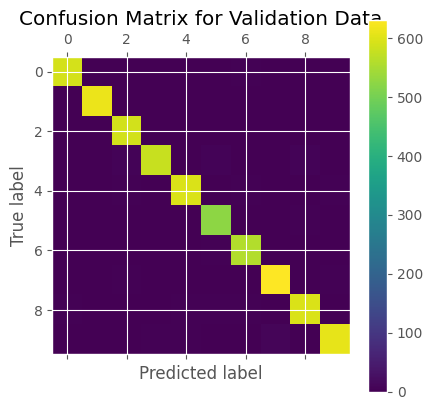


Making Predictions on Test Input Images...

Calculating Accuracy of Trained Classifier on Test Data... 

 Creating Confusion Matrix for Test Data...

Predicted Labels for Test Images:  [7 2 1 ... 4 5 6]

Accuracy of Classifier on Test Images:  0.9785

Confusion Matrix for Test Data: 
 [[ 972    0    1    1    0    3    1    0    2    0]
 [   0 1127    2    2    0    0    3    0    1    0]
 [   8    0 1005    0    2    0    5    8    3    1]
 [   0    2    2  985    0    6    0    5    6    4]
 [   1    0    3    0  967    0    4    0    0    7]
 [   2    1    2   13    1  862    2    1    5    3]
 [   4    5    1    0    3    6  937    0    2    0]
 [   0   10    8    1    2    0    0 1001    0    6]
 [   6    1    1    3    4    4    1    2  950    2]
 [   3    7    1    4    7    3    1    2    2  979]]


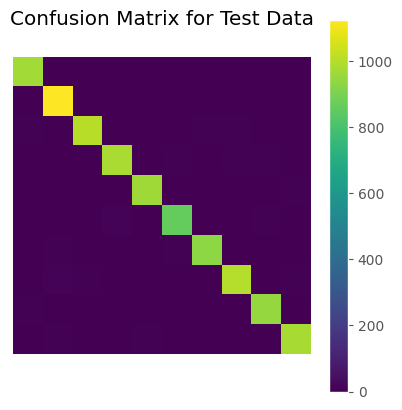

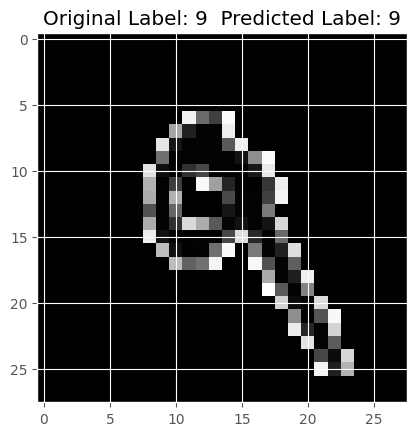

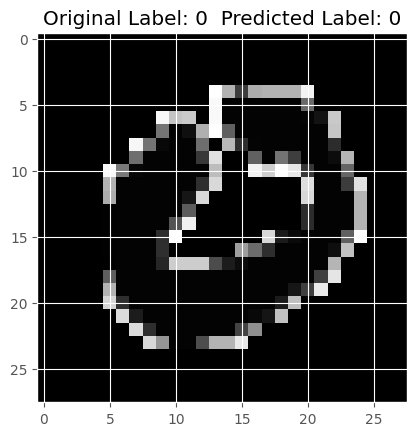

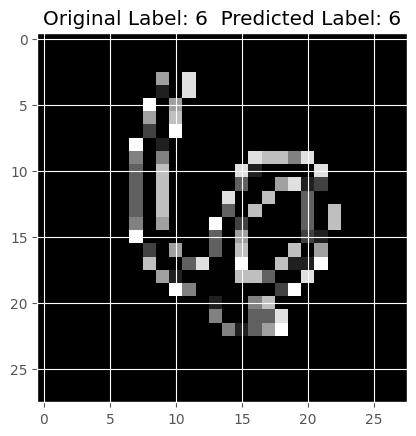

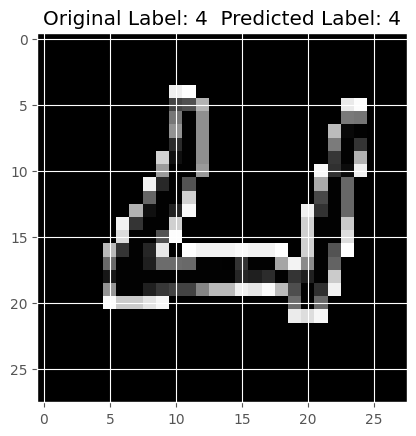

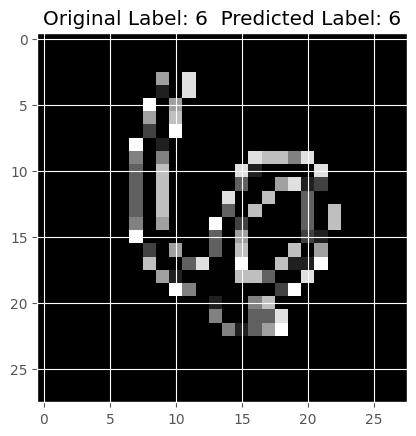

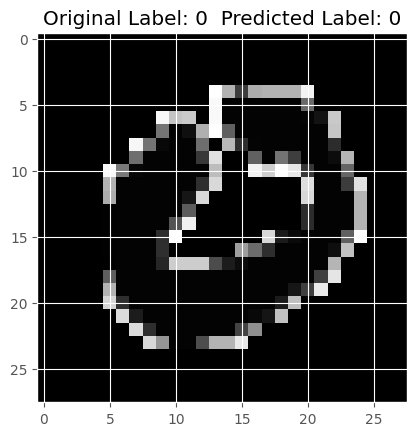

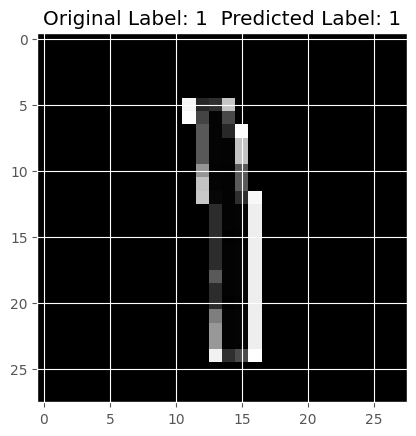

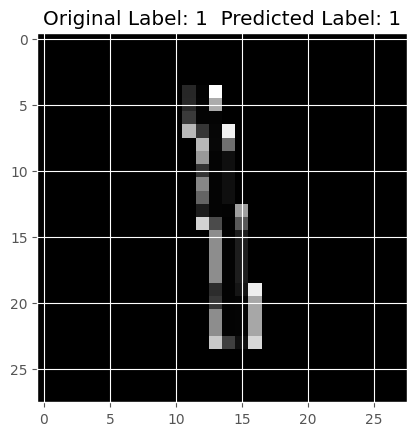

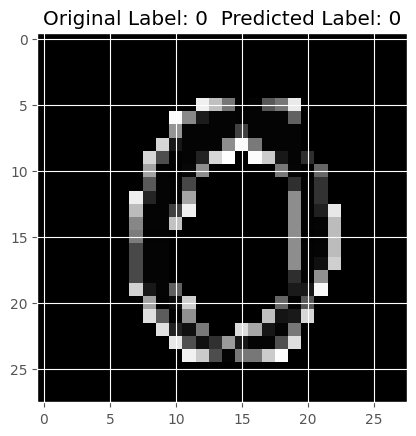

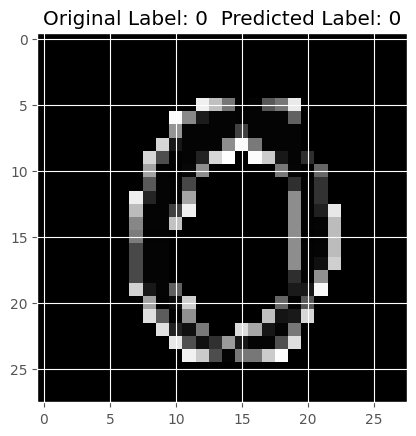

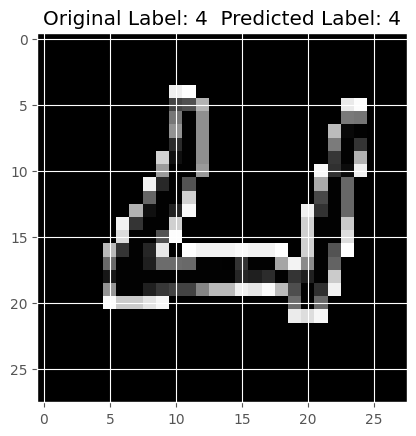

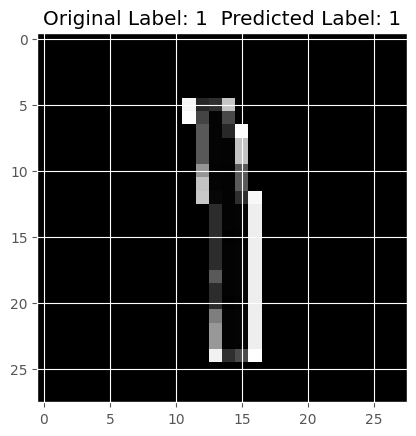

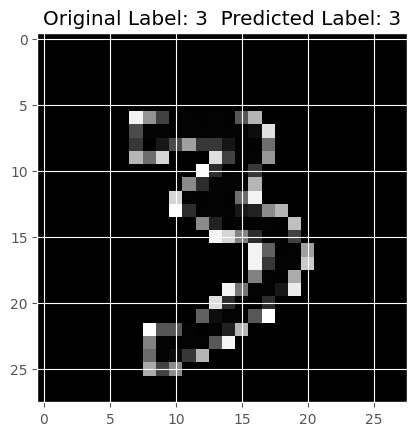

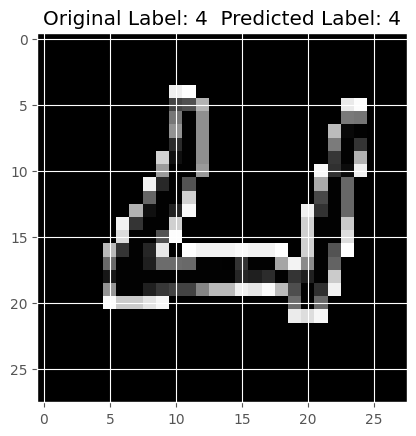

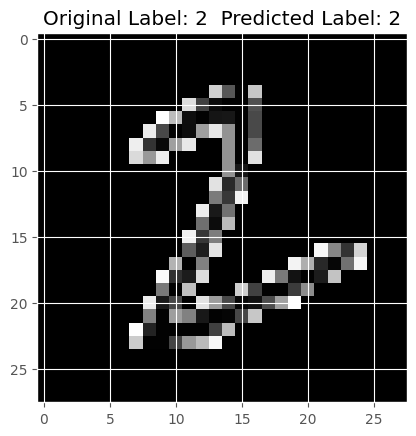

In [1]:
#support vector machine
import sys
import numpy as np
import pickle
from sklearn import model_selection, svm, preprocessing
from sklearn.metrics import accuracy_score,confusion_matrix
from MNIST_Dataset_Loader.mnist_loader import MNIST
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')


# Save all the Print Statements in a Log file.
'''old_stdout = sys.stdout
log_file = open("summary.log","w")
sys.stdout = log_file'''

# Load MNIST Data
print('\nLoading MNIST Data...')
data = MNIST('./MNIST_Dataset_Loader/dataset/')

print('\nLoading Training Data...')
img_train, labels_train = data.load_training()
train_img = np.array(img_train)
train_labels = np.array(labels_train)

print('\nLoading Testing Data...')
img_test, labels_test = data.load_testing()
test_img = np.array(img_test)
test_labels = np.array(labels_test)


#Features
X = train_img

#Labels
y = train_labels

# Prepare Classifier Training and Testing Data
print('\nPreparing Classifier Training and Validation Data...')
X_train, X_test, y_train, y_test = model_selection.train_test_split(X,y,test_size=0.1)


# Pickle the Classifier for Future Use
print('\nSVM Classifier with gamma = 0.1; Kernel = polynomial')
print('\nPickling the Classifier for Future Use...')
clf = svm.SVC(gamma=0.1, kernel='poly')
clf.fit(X_train,y_train)

with open('MNIST_SVM.pickle','wb') as f:
	pickle.dump(clf, f)

pickle_in = open('MNIST_SVM.pickle','rb')
clf = pickle.load(pickle_in)

print('\nCalculating Accuracy of trained Classifier...')
acc = clf.score(X_test,y_test)

print('\nMaking Predictions on Validation Data...')
y_pred = clf.predict(X_test)

print('\nCalculating Accuracy of Predictions...')
accuracy = accuracy_score(y_test, y_pred)

print('\nCreating Confusion Matrix...')
conf_mat = confusion_matrix(y_test,y_pred)

print('\nSVM Trained Classifier Accuracy: ',acc)
print('\nPredicted Values: ',y_pred)
print('\nAccuracy of Classifier on Validation Images: ',accuracy)
print('\nConfusion Matrix: \n',conf_mat)

# Plot Confusion Matrix Data as a Matrix
plt.matshow(conf_mat)
plt.title('Confusion Matrix for Validation Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


print('\nMaking Predictions on Test Input Images...')
test_labels_pred = clf.predict(test_img)

print('\nCalculating Accuracy of Trained Classifier on Test Data... ')
acc = accuracy_score(test_labels,test_labels_pred)

print('\n Creating Confusion Matrix for Test Data...')
conf_mat_test = confusion_matrix(test_labels,test_labels_pred)

print('\nPredicted Labels for Test Images: ',test_labels_pred)
print('\nAccuracy of Classifier on Test Images: ',acc)
print('\nConfusion Matrix for Test Data: \n',conf_mat_test)

# Plot Confusion Matrix for Test Data
plt.matshow(conf_mat_test)
plt.title('Confusion Matrix for Test Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.axis('off')
plt.show()

'''sys.stdout = old_stdout
log_file.close()'''


# Show the Test Images with Original and Predicted Labels
a = np.random.randint(1,40,15)
for i in a:
	two_d = (np.reshape(test_img[i], (28, 28)) * 255).astype(np.uint8)
	plt.title('Original Label: {0}  Predicted Label: {1}'.format(test_labels[i],test_labels_pred[i]))
	plt.imshow(two_d, interpolation='nearest',cmap='gray')
	plt.show()
#---------------------- EOC ---------------------#

